# ForesightEstate — исследование и подготовка данных

Главная тетрадка проекта: этап 1 — исследование данных, этап 2 — предварительная обработка. Модели здесь не обучаются.

Запускайте ячейки сверху вниз из корня проекта или из папки `notebooks`. Исходный CSV загружается один раз. Для перевода цен используются сохранённые курсы TCMB; если файла курсов нет, первый запуск потребует интернет.


# Этап 1. Исследование данных (EDA)

**Задача проекта:** прогнозировать цену жилой недвижимости по характеристикам объявления. Здесь мы изучаем данные до очистки и обучения моделей. Таблицы и графики строятся из файла `data/real_estate_data.csv`; исходный файл не меняется.

**Как читать ноутбук:** после каждой таблицы и каждого графика идёт простое пояснение. Числа относятся к историческим объявлениям, а не к фактическим ценам сделок.

## 1.1. Знакомство с данными

Источник — набор объявлений Zingat; описание полей находится в `data/zingat_data_info.docx`. Целевая переменная — `price` с единицей `price_currency`. Площадь `size` дана в м², `tom` — в днях. `building_age` означает возраст здания, а не год постройки. `address` записан как город/район/микрорайон.

# Описание данных

Имена полей приведены как в CSV; значения переводятся только при показе. Исходный файл не меняется.

| Поле | Что означает |
|---|---|
| id | Уникальный номер объявления. |
| type | Общий тип недвижимости: Konut — жильё. |
| sub_type | Подтип: квартира, вилла, отдельный дом и др. |
| start_date | Дата публикации; исходный формат месяц/день/год. |
| end_date | Дата снятия объявления; может быть пустой. |
| listing_type | Код типа объявления. По ценам 1 предположительно продажа, 2 аренда; словарь не подтверждает коды. Код 3 не интерпретируем. |
| tom | Срок объявления на рынке, дни; для прогноза при публикации недоступен. |
| building_age | Возраст здания в годах или интервал, например 6-10 arası — от 6 до 10 лет. Это не год постройки. |
| total_floor_count | Этажность здания; бывают диапазоны и значения «20 и более». |
| floor_no | Этаж объекта; Yüksek Giriş — высокий первый этаж. |
| room_count | Формат 2+1: две комнаты и гостиная. |
| size | Площадь, м². |
| address | Город/район/микрорайон. Собственные имена не переводим. |
| furnished | Меблировка; в этом файле столбец полностью пуст. |
| heating_type | Тип отопления; Kombi (Doğalgaz) — газовый котёл. |
| price | Цена объявления, целевая переменная. |
| price_currency | TRY — турецкая лира, EUR — евро, GBP — фунт, USD — доллар США. |

Краткий словарь: Daire — квартира; Villa — вилла; Müstakil Ev — отдельный дом; Rezidans — резиденция; Yazlık — летний дом; Komple Bina — здание целиком; Prefabrik Ev — сборный дом; Çiftlik Evi — фермерский дом; Kooperatif — кооперативное жильё; Loft — лофт. arası означает «от … до …», ve üzeri — «и более».


In [2]:
# Загружаем данные; путь работает из корня проекта и из папки notebooks.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = next((p for p in [Path("data/real_estate_data.csv"), Path("../data/real_estate_data.csv")] if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/real_estate_data.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)
original_columns = df.columns.tolist()

# Переводы используются только для показа; df и sale остаются с исходными значениями.
COLUMN_RU={"id":"Номер (id)","type":"Тип (type)","sub_type":"Подтип жилья (sub_type)",
"start_date":"Дата публикации (start_date)","end_date":"Дата снятия (end_date)",
"listing_type":"Тип объявления (listing_type)","tom":"Дней на рынке (tom)",
"building_age":"Возраст здания (building_age)","total_floor_count":"Этажей в здании (total_floor_count)",
"floor_no":"Этаж (floor_no)","room_count":"Комнаты (room_count)","size":"Площадь, м² (size)",
"address":"Адрес (address)","furnished":"Меблировка (furnished)",
"heating_type":"Отопление (heating_type)","price":"Цена (price)",
"price_currency":"Валюта (price_currency)"}
TYPE_RU={"Konut":"Жильё"}
SUBTYPE_RU={"Daire":"Квартира","Villa":"Вилла","Müstakil Ev":"Отдельный дом",
"Rezidans":"Резиденция","Yazlık":"Летний дом","Komple Bina":"Здание целиком",
"Prefabrik Ev":"Сборный дом","Çiftlik Evi":"Фермерский дом",
"Köşk / Konak / Yalı":"Особняк / усадьба / прибрежный дом",
"Yalı Dairesi":"Квартира в прибрежном доме","Kooperatif":"Кооперативное жильё","Loft":"Лофт"}
AGE_RU={f"{a}-{b} arası":f"{a}–{b} лет" for a,b in [(6,10),(11,15),(16,20),(21,25),(26,30),(31,35),(36,40)]}
AGE_RU["40 ve üzeri"]="40 лет и старше"
FLOOR_RU={"Yüksek Giriş":"Высокий первый этаж","Giriş kat":"Первый этаж",
"Zemin kat":"Нулевой этаж","Bahçe katı":"Садовый этаж","Çatı Katı":"Мансардный этаж"}
HEATING_RU={"Fancoil":"Фанкойл","Klima":"Кондиционер","Yok":"Нет отопления",
"Kombi (Doğalgaz)":"Газовый котёл","Kombi (Elektrikli)":"Электрический котёл",
"Kalorifer (Doğalgaz)":"Центральное газовое отопление",
"Kalorifer (Kömür)":"Центральное угольное отопление",
"Merkezi Sistem":"Центральное отопление",
"Merkezi Sistem (Isı Payı Ölçer)":"Центральное отопление со счётчиком",
"Yerden Isıtma":"Тёплый пол","Soba (Kömür)":"Угольная печь",
"Soba (Doğalgaz)":"Газовая печь","Güneş Enerjisi":"Солнечная энергия",
"Jeotermal":"Геотермальное отопление","Kat Kaloriferi":"Поквартирное отопление",
"Kalorifer (Akaryakıt)":"Жидкотопливное отопление"}
FLOOR_RU.update({"20 ve üzeri":"20 и более","Kot 1":"Цокольный уровень 1",
"Kot 2":"Цокольный уровень 2","Kot 3":"Цокольный уровень 3",
"Kot 4":"Цокольный уровень 4","Asma Kat":"Антресоль",
"Müstakil":"Отдельный дом","Zemin Kat":"Нулевой этаж",
"En Üst Kat":"Верхний этаж","Giriş Katı":"Входной этаж",
"Çatı Katı":"Мансардный этаж","Teras Kat":"Террасный этаж",
"Komple":"Здание целиком","Bodrum Kat":"Подвальный этаж"})
FLOOR_COUNT_RU={"20 ve üzeri":"20 и более","10-20 arası":"10–20"}
def show_ru(frame):
    shown=frame.copy()
    for col,dictionary in [("type",TYPE_RU),("sub_type",SUBTYPE_RU),
                           ("building_age",AGE_RU),("total_floor_count",FLOOR_COUNT_RU),("floor_no",FLOOR_RU),
                           ("heating_type",HEATING_RU)]:
        if col in shown.columns:
            shown[col]=shown[col].replace(dictionary)
    return shown.rename(columns=COLUMN_RU)
print(f"Размер: {len(df):,} строк × {len(original_columns)} столбцов")

def show_table(frame):
    # Показываем плоскую таблицу без технического числового индекса.
    display(frame.style.hide(axis="index").format(precision=2, thousands=" ", na_rep="—"))


Размер: 403,487 строк × 17 столбцов


в датасете 403 487 объявлений и 17 исходных признаков. Это достаточно большая выборка для сравнения групп, но качество каждого поля нужно проверить отдельно.

### Типы и заполненность полей

In [3]:
# Таблица показывает формат, число заполненных и число уникальных значений.
schema = pd.DataFrame({"тип": df.dtypes.astype(str),
                       "заполнено": df.notna().sum(),
                       "уникальных": df.nunique(dropna=True)})
show_table(schema.rename(index=COLUMN_RU).rename_axis("Поле").reset_index())

Поле,тип,заполнено,уникальных
Номер (id),int64,403 487,403 487
Тип (type),object,403 487,1
Подтип жилья (sub_type),object,403 487,12
Дата публикации (start_date),object,403 487,181
Дата снятия (end_date),object,266 298,181
Тип объявления (listing_type),int64,403 487,3
Дней на рынке (tom),int64,403 487,181
Возраст здания (building_age),object,376 097,14
Этажей в здании (total_floor_count),object,375 466,12
Этаж (floor_no),object,368 191,35


`price` и `size` числовые, но `building_age`, `room_count`, этажи и даты пока записаны строками. `type` имеет одно значение — «Konut» (жильё); `furnished` вообще не заполнен. Строковые поля потребуется преобразовать перед обучением.

### Примеры записей

In [4]:
# Первые строки позволяют увидеть исходный формат.
show_table(show_ru(df.head(5)).reset_index(drop=True))

Номер (id),Тип (type),Подтип жилья (sub_type),Дата публикации (start_date),Дата снятия (end_date),Тип объявления (listing_type),Дней на рынке (tom),Возраст здания (building_age),Этажей в здании (total_floor_count),Этаж (floor_no),Комнаты (room_count),"Площадь, м² (size)",Адрес (address),Меблировка (furnished),Отопление (heating_type),Цена (price),Валюта (price_currency)
1,Жильё,Резиденция,12/10/18,1/9/19,2,30,0,20 и более,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,—,Фанкойл,3 500.00,TRY
2,Жильё,Квартира,2/13/19,—,1,14,0,20 и более,20 и более,1+0,43.00,İstanbul/Kartal/Kordonboyu,—,Фанкойл,490 000.00,TRY
3,Жильё,Квартира,10/9/18,11/8/18,1,30,0,1,Высокий первый этаж,2+1,—,Tekirdağ/Çorlu/Reşadiye,—,Фанкойл,155 000.00,TRY
4,Жильё,Резиденция,9/10/18,10/10/18,1,30,3,20 и более,20 и более,6+1,450.00,İstanbul/Beşiktaş/Levent,—,Фанкойл,32 500 000.00,TRY
5,Жильё,Резиденция,12/10/18,1/9/19,1,30,0,20 и более,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,—,Фанкойл,1 450 000.00,TRY


встречаются и низкие, и высокие цены, разные валюты и пустая площадь. Нельзя считать, что все строки описывают один и тот же рынок.

In [5]:
# Последние строки помогают увидеть, одинаков ли формат в конце файла.
show_table(show_ru(df.tail(5)).reset_index(drop=True))

C:\Users\2.0\AppData\Local\Temp\ipykernel_24240\3936902863.py:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shown[col]=shown[col].replace(dictionary)


Номер (id),Тип (type),Подтип жилья (sub_type),Дата публикации (start_date),Дата снятия (end_date),Тип объявления (listing_type),Дней на рынке (tom),Возраст здания (building_age),Этажей в здании (total_floor_count),Этаж (floor_no),Комнаты (room_count),"Площадь, м² (size)",Адрес (address),Меблировка (furnished),Отопление (heating_type),Цена (price),Валюта (price_currency)
403 483,Жильё,Квартира,9/18/18,—,2,162,—,—,—,+,—,İstanbul/Sultanbeyli/Adil,—,—,1 500.00,TRY
403 484,Жильё,Квартира,10/11/18,—,1,139,—,—,—,2+1,—,Sakarya/Adapazarı/Cumhuriyet,—,—,120 000.00,TRY
403 485,Жильё,Квартира,11/22/18,—,1,97,—,—,—,1+1,—,Antalya/Alanya/Saray,—,—,48 000.00,EUR
403 486,Жильё,Квартира,2/21/19,—,2,6,—,—,—,2+1,2.00,Aydın/Kuşadası/Türkmen,—,—,900.00,TRY
403 487,Жильё,Квартира,1/15/19,1/18/19,1,3,—,—,—,3+1,140.00,Kayseri/Melikgazi/Alpaslan,—,—,210 000.00,TRY


структура столбцов сохраняется, но встречаются записи с `room_count='+'` и пропущенной площадью — нужен контроль качества.

In [6]:
# Случайная строка воспроизводима благодаря фиксированному seed.
show_table(show_ru(df.sample(1, random_state=RANDOM_STATE)).reset_index(drop=True))

Номер (id),Тип (type),Подтип жилья (sub_type),Дата публикации (start_date),Дата снятия (end_date),Тип объявления (listing_type),Дней на рынке (tom),Возраст здания (building_age),Этажей в здании (total_floor_count),Этаж (floor_no),Комнаты (room_count),"Площадь, м² (size)",Адрес (address),Меблировка (furnished),Отопление (heating_type),Цена (price),Валюта (price_currency)
60 624,Жильё,Квартира,11/20/18,2/23/19,1,95,6–10 лет,5,1,2+1,120.00,Antalya/Alanya/Oba,—,Кондиционер,240 000.00,TRY


поле `room_count` выглядит как «2+1» (две комнаты и гостиная), а `building_age` может быть диапазоном вроде «6-10 arası».

In [7]:
# Даты публикации парсим в явном формате месяц/день/год.
dates = pd.to_datetime(df.start_date, format="%m/%d/%y", errors="coerce")
print("Период:", dates.min().date(), "—", dates.max().date())
show_table(df.price_currency.value_counts(dropna=False).rename_axis("Валюта").reset_index(name="Объявлений"))

Период: 2018-08-31 — 2019-02-27


Валюта,Объявлений
TRY,400 677
EUR,922
—,715
GBP,621
USD,552


объявления опубликованы с 31.08.2018 по 27.02.2019. Основная валюта — TRY, но также есть EUR, GBP и USD. Цены разных валют без пересчёта сравнивать нельзя; исторический период ограничивает применимость модели к сегодняшнему рынку.

## 1.2. Описательная статистика

Числовая сводка показывает центр распределения и крайние значения. `id` и `listing_type` технически числа, но по смыслу идентификатор и код категории; их среднее значение не интерпретируется.

In [8]:
# Считаем минимум, квартили, медиану, среднее, максимум и стандартное отклонение.
numeric_summary = df.select_dtypes(include="number").describe(percentiles=[.25, .5, .75]).T
show_table(numeric_summary[["count","min","25%","50%","mean","75%","max","std"]].rename(index=COLUMN_RU).rename_axis("Признак").reset_index())

Признак,count,min,25%,50%,mean,75%,max,std
Номер (id),403 487.00,1.00,100 872.50,201 744.00,201 744.00,302 615.50,403 487.00,116 476.81
Тип объявления (listing_type),403 487.00,1.00,1.00,1.00,1.29,2.00,3.00,0.47
Дней на рынке (tom),403 487.00,0.00,29.00,40.00,57.02,90.00,180.00,44.36
"Площадь, м² (size)",257 481.00,1.00,85.00,110.00,279.35,140.00,948 235.00,9 429.20
Меблировка (furnished),0.00,—,—,—,—,—,—,—
Цена (price),402 772.00,-250.00,2 500.00,199 000.00,354 641.66,342 000.00,2 000 000 000.00,4 809 502.70


цена достигает отрицательных значений и экстремально высоких сумм; площадь — до 948 235 м². Поэтому средние сильно зависят от выбросов. Для описания «типичного» объекта полезнее медиана и квартили.

In [9]:
# Считаем число категорий и наиболее частое значение для каждого текстового поля.
categorical_cols = df.select_dtypes(include=["object"]).columns
category_summary = pd.DataFrame({
    "уникальных": df[categorical_cols].nunique(dropna=True),
    "наиболее частое": [df[x].mode(dropna=True).iloc[0] if df[x].notna().any() else None for x in categorical_cols],
    "частота": [df[x].value_counts(dropna=True).iloc[0] if df[x].notna().any() else 0 for x in categorical_cols]
}, index=categorical_cols)
for col,dictionary in [("type",TYPE_RU),("sub_type",SUBTYPE_RU),("building_age",AGE_RU),("heating_type",HEATING_RU)]:
    if col in category_summary.index:
        value=category_summary.loc[col,"наиболее частое"]
        category_summary.loc[col,"наиболее частое"]=dictionary.get(value,value)
show_table(category_summary.rename(index=COLUMN_RU).rename_axis("Поле").reset_index())

Поле,уникальных,наиболее частое,частота
Тип (type),1,Жильё,403 487
Подтип жилья (sub_type),12,Квартира,354 549
Дата публикации (start_date),181,10/11/18,4 064
Дата снятия (end_date),181,12/19/18,3 048
Возраст здания (building_age),14,0,140 174
Этажей в здании (total_floor_count),12,4,83 082
Этаж (floor_no),35,2,65 864
Комнаты (room_count),37,3+1,157 363
Адрес (address),7 842,Balıkesir/Edremit/Akçay,5 611
Отопление (heating_type),16,Газовый котёл,204 150


адрес имеет тысячи значений, поэтому прямое one-hot-кодирование полного адреса будет громоздким. Самый частый тип жилья — квартира (`Daire`), наиболее частая конфигурация — `3+1`. Это стоит учитывать при сравнении средних по группам.

### Частоты важных категорий

In [10]:
# Показываем частоты подтипов жилья.
show_table(df.sub_type.value_counts(dropna=False).rename(index=SUBTYPE_RU).rename_axis("Тип жилья").reset_index(name="Объявлений"))

Тип жилья,Объявлений
Квартира,354 549
Вилла,21 324
Отдельный дом,9 563
Резиденция,7 716
Летний дом,5 929
Здание целиком,2 607
Сборный дом,679
Фермерский дом,528
Особняк / усадьба / прибрежный дом,301
Квартира в прибрежном доме,187


квартир намного больше, чем вилл и других подтипов. Сравнение групп должно сопровождаться числом объявлений, иначе маленькая группа может дать нестабильную оценку.

In [11]:
# Показываем наиболее частые конфигурации комнат.
show_table(df.room_count.value_counts(dropna=False).head(12).rename_axis("Комнаты").reset_index(name="Объявлений"))

Комнаты,Объявлений
3+1,157 363
2+1,138 677
1+1,39 134
4+1,37 472
5+1,8 219
4+2,4 540
5+2,2 926
+,2 898
3+2,2 673
1+0,2 612


`3+1` и `2+1` доминируют. Есть значение `+`, из которого число комнат не извлечь — оно станет пропуском после преобразования.

In [12]:
# Возраст здания бывает числом или интервалом.
show_table(df.building_age.value_counts(dropna=False).rename(index=AGE_RU).rename_axis("Возраст здания").reset_index(name="Объявлений"))

Возраст здания,Объявлений
0,140 174
6–10 лет,50 495
11–15 лет,32 309
16–20 лет,31 333
—,27 390
1,20 355
4,19 032
21–25 лет,18 438
2,17 466
3,15 651


0 лет — самая частая запись; часть возраста дана диапазонами. Точный год постройки в наборе не указан. Ниже диапазоны временно заменяются серединами только для EDA.

### Почему выделяем сопоставимый сегмент

In [13]:
# Сравниваем медианные цены по коду типа объявления и валюте.
show_table(df.groupby(["listing_type","price_currency"],dropna=False).price.agg(["count","median"]).reset_index().rename(columns={"listing_type":"Код объявления","price_currency":"Валюта","count":"Объявлений","median":"Медианная цена"}))

Код объявления,Валюта,Объявлений,Медианная цена
1,EUR,891,85 000.00
1,GBP,581,75 000.00
1,TRY,284 496,270 000.00
1,USD,452,635 000.00
1,—,0,—
2,EUR,31,900.00
2,GBP,40,400.00
2,TRY,113 948,1 200.00
2,USD,99,2 500.00
2,—,0,—


медиана для кода `listing_type=1` и TRY — 270 000, для кода 2 — 1 200. Это согласуется с продажей и арендой соответственно, но числовые коды не объяснены в словаре. Интерпретация кода 1 как продажи остаётся предположением до подтверждения источником.

In [14]:
# Оставляем код 1, TRY и положительные цены; исходный df остаётся неизменным.
sale = df.loc[(df.listing_type == 1) & (df.price_currency == "TRY") & (df.price > 0)].copy()
sale["city"] = sale.address.str.split("/").str[0]
sale["district"] = sale.address.str.split("/").str[1]
sale["rooms"] = pd.to_numeric(sale.room_count.str.split("+", regex=False).str[0], errors="coerce")
age_map = {"6-10 arası":8,"11-15 arası":13,"16-20 arası":18,"21-25 arası":23,
           "26-30 arası":28,"31-35 arası":33,"36-40 arası":38,"40 ve üzeri":42}
sale["age_approx"] = pd.to_numeric(sale.building_age.replace(age_map), errors="coerce")
sale["size_valid"] = sale["size"].where(sale["size"].between(15,1000))
sale["log_price"] = np.log10(sale.price)
print(f"Сопоставимый сегмент: {len(sale):,} объявлений")
sale_summary=sale[["price","size_valid","rooms","age_approx"]].describe(percentiles=[.01,.25,.5,.75,.99]).T
show_table(sale_summary.rename(index={"price":"Цена, TRY","size_valid":"Площадь, м²",
                                   "rooms":"Комнаты","age_approx":"Возраст здания, лет"}).rename_axis("Признак").reset_index())

Сопоставимый сегмент: 284,468 объявлений


Признак,count,mean,std,min,1%,25%,50%,75%,99%,max
"Цена, TRY",284 468.00,491 812.88,5 310 470.76,1.00,63 500.00,185 000.00,270 000.00,420 000.00,3 700 000.00,2 000 000 000.00
"Площадь, м²",182 972.00,127.85,71.76,15.00,45.00,90.00,115.00,145.00,400.00,1 000.00
Комнаты,282 563.00,2.73,1.05,0.00,1.00,2.00,3.00,3.00,6.00,11.00
"Возраст здания, лет",267 492.00,5.86,8.23,0.00,0.00,0.00,2.00,8.00,33.00,42.00


284 468 объявлений с положительной ценой в TRY. Медиана — 270 000 TRY, а среднее — около 492 000 TRY: его поднимают дорогие объявления. Медианная допустимая площадь — 115 м². Отбор площади 15–1000 м² здесь нужен только для понятных графиков, это ещё не окончательное правило очистки.

In [15]:
# Коэффициент асимметрии измеряет длину правого хвоста цены.
print("Асимметрия цены:", round(sale.price.skew(), 2))

Асимметрия цены: 297.66


коэффициент асимметрии около 297,66 — распределение цены сильно скошено вправо. В такой ситуации полезно смотреть цену в логарифмическом масштабе и отдельно анализировать крайне дорогие объекты.

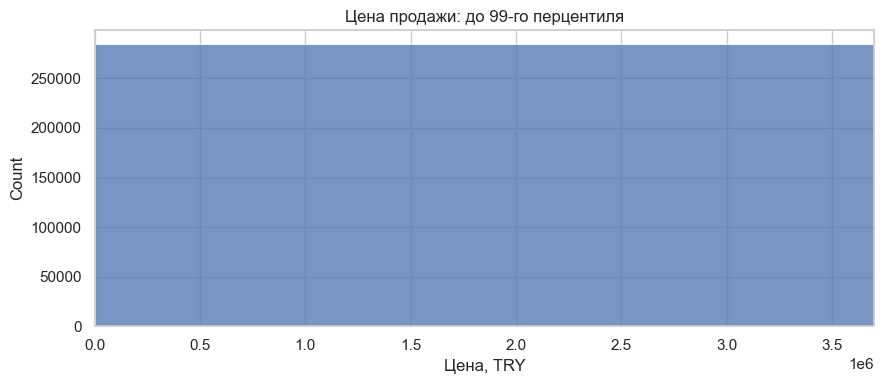

In [16]:
# Гистограмма с ограничением оси до 99-го перцентиля для читаемости.
plt.figure(figsize=(9,4))
sns.histplot(sale.price, bins=80)
plt.xlim(0,sale.price.quantile(.99)); plt.xlabel("Цена, TRY")
plt.title("Цена продажи: до 99-го перцентиля")
plt.tight_layout(); plt.show()

большинство объявлений сосредоточено на низких и средних ценах; справа остаётся длинный хвост. Ограничение оси скрывает только отображение верхнего 1%, данные не удалены.

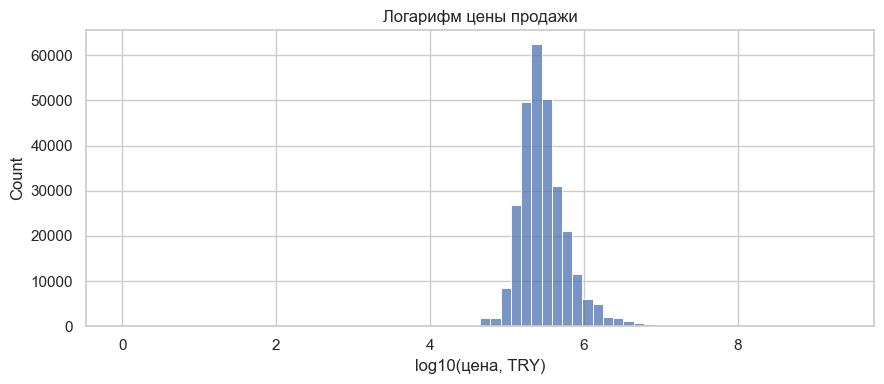

In [17]:
# Логарифмическая шкала раскрывает форму основного распределения.
plt.figure(figsize=(9,4))
sns.histplot(sale.log_price,bins=70)
plt.xlabel("log10(цена, TRY)"); plt.title("Логарифм цены продажи")
plt.tight_layout(); plt.show()

после преобразования основная масса цен видна лучше. Это аргумент проверить логарифмирование целевой переменной при моделировании, но качество нужно оценивать в исходных TRY.

## 1.3. Визуальный анализ

Пять типов визуализации: гистограммы, диаграммы рассеяния, boxplot, тепловая карта и столбчатые диаграммы. Каждый график отвечает на один вопрос. Для читаемости некоторые оси ограничены, а scatter использует фиксированную подвыборку; исходные данные от этого не меняются.

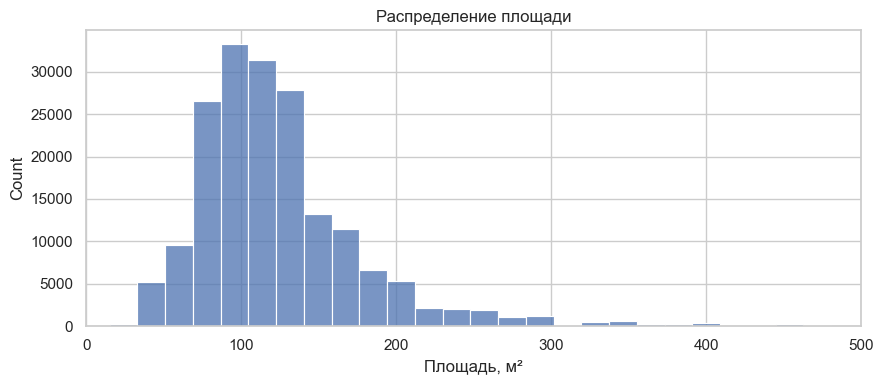

In [18]:
# Площадь: показываем правдоподобные записанные значения, без пропусков.
plt.figure(figsize=(9,4))
sns.histplot(sale.size_valid.dropna(),bins=55)
plt.xlim(0,500); plt.xlabel("Площадь, м²"); plt.title("Распределение площади")
plt.tight_layout(); plt.show()

основная масса объявлений описывает объекты примерно среднего размера; медиана среди допустимых записей — 115 м². Длинный правый хвост означает, что большие дома и здания нужно анализировать с учётом типа жилья.

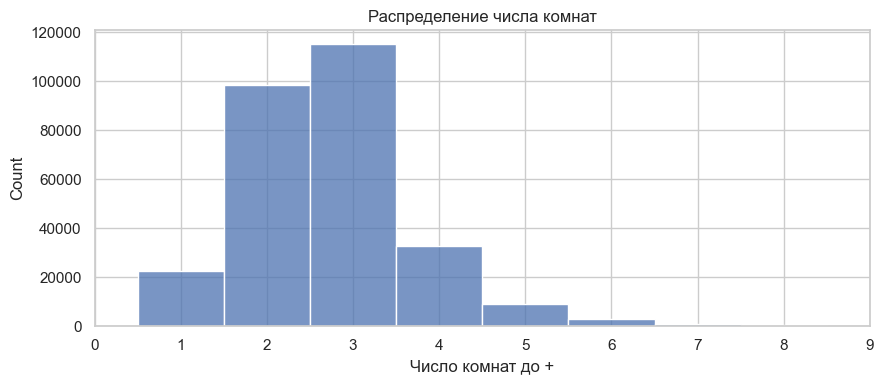

In [19]:
# Количество комнат: число до знака «+».
plt.figure(figsize=(9,4))
sns.histplot(sale.rooms.dropna(),discrete=True)
plt.xlim(0,9); plt.xlabel("Число комнат до +"); plt.title("Распределение числа комнат")
plt.tight_layout(); plt.show()

наиболее типичны 2–3 комнаты. Значение вроде `3+1` здесь превращено в 3; гостиная отдельно не учитывается. Записи вида `+` становятся пропусками.

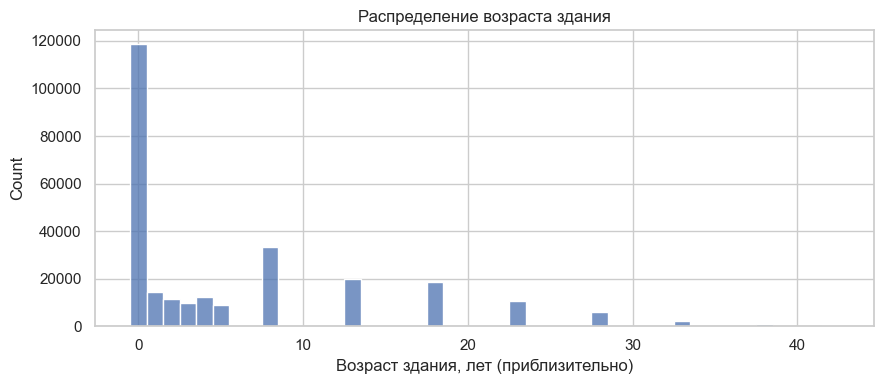

In [20]:
# Интервалы возраста заменены серединами для ориентировочного графика.
plt.figure(figsize=(9,4))
sns.histplot(sale.age_approx.dropna(),discrete=True)
plt.xlabel("Возраст здания, лет (приблизительно)")
plt.title("Распределение возраста здания")
plt.tight_layout(); plt.show()

много объявлений с возрастом 0 лет. Пики на 8, 13, 18 и других значениях частично созданы заменой диапазонов их серединами; это не точные годы постройки.

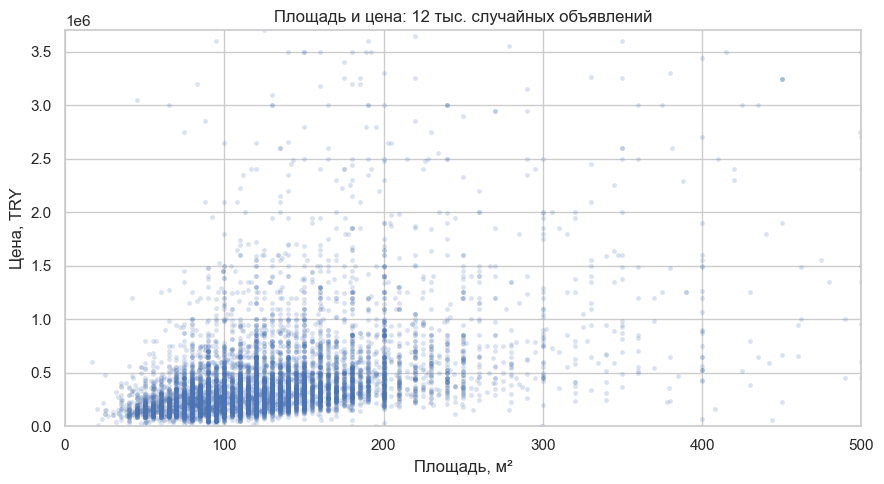

In [21]:
# Случайная подвыборка фиксирована, чтобы рисунок был воспроизводим.
sample = sale.loc[sale.size_valid.notna()].sample(n=min(12000,sale.size_valid.notna().sum()),random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
sns.scatterplot(data=sample,x="size_valid",y="price",alpha=.2,s=12,linewidth=0)
plt.xlim(0,500); plt.ylim(0,sale.price.quantile(.99))
plt.xlabel("Площадь, м²"); plt.ylabel("Цена, TRY")
plt.title("Площадь и цена: 12 тыс. случайных объявлений")
plt.tight_layout(); plt.show()

в целом более просторное жильё дороже, но при одной площади цены сильно различаются. Значит, одной площади для прогноза недостаточно — важны локация, тип объекта и другие характеристики.

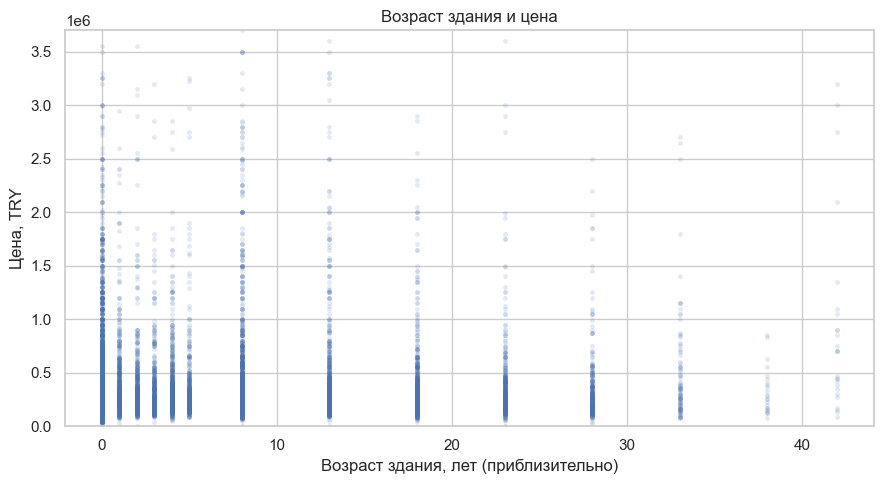

In [22]:
# Проверяем, видна ли прямая связь возраста здания с ценой.
age_sample = sale.loc[sale.age_approx.notna()].sample(n=min(12000,sale.age_approx.notna().sum()),random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
sns.scatterplot(data=age_sample,x="age_approx",y="price",alpha=.15,s=12,linewidth=0)
plt.ylim(0,sale.price.quantile(.99))
plt.xlabel("Возраст здания, лет (приблизительно)"); plt.ylabel("Цена, TRY")
plt.title("Возраст здания и цена")
plt.tight_layout(); plt.show()

явной прямой зависимости на общей выборке не видно. Возраст может влиять по-разному в разных городах и типах жилья; проверим это при моделировании.

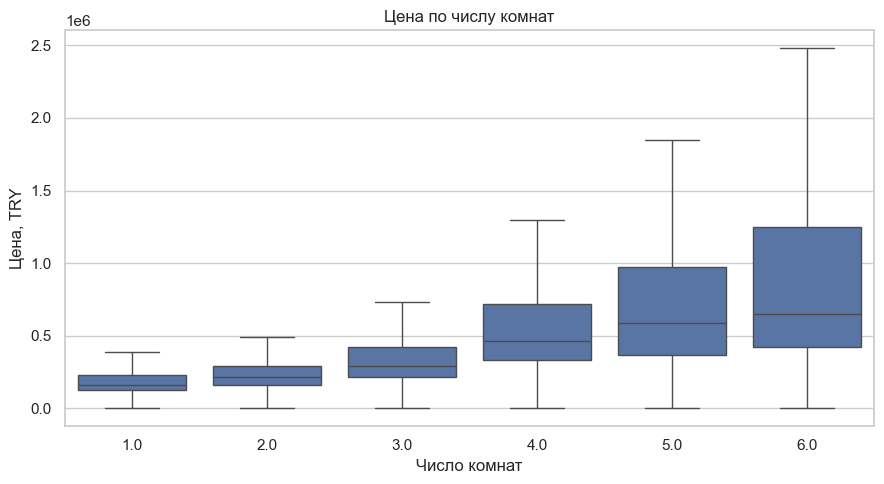

In [23]:
# Boxplot показывает медиану, квартили и разброс цен по комнатам.
limited = sale.loc[sale.price.le(sale.price.quantile(.99)) & sale.rooms.between(1,6)]
plt.figure(figsize=(9,5))
sns.boxplot(data=limited,x="rooms",y="price",showfliers=False)
plt.xlabel("Число комнат"); plt.ylabel("Цена, TRY")
plt.title("Цена по числу комнат")
plt.tight_layout(); plt.show()

медиана цены обычно растёт с числом комнат, но диапазоны разных групп сильно перекрываются. Число комнат полезно, однако само по себе не определяет цену. Точки выбросов скрыты для читаемости, строки сохранены.

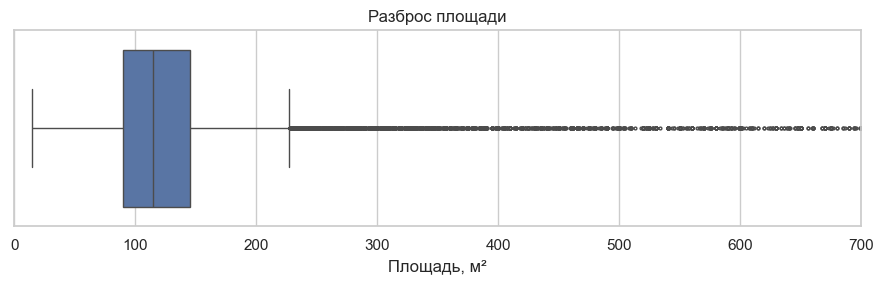

In [24]:
# Boxplot площади показывает потенциальные выбросы по правилу 1,5×IQR.
plt.figure(figsize=(9,3))
sns.boxplot(x=sale.size_valid.dropna(),showfliers=True,flierprops={"markersize":2})
plt.xlim(0,700); plt.xlabel("Площадь, м²")
plt.title("Разброс площади")
plt.tight_layout(); plt.show()

выше верхнего «уса» есть крупные объекты. Часть может быть реальной (например, виллы), поэтому автоматически удалять их нельзя. Сначала нужно проверить тип жилья и достоверность площади.

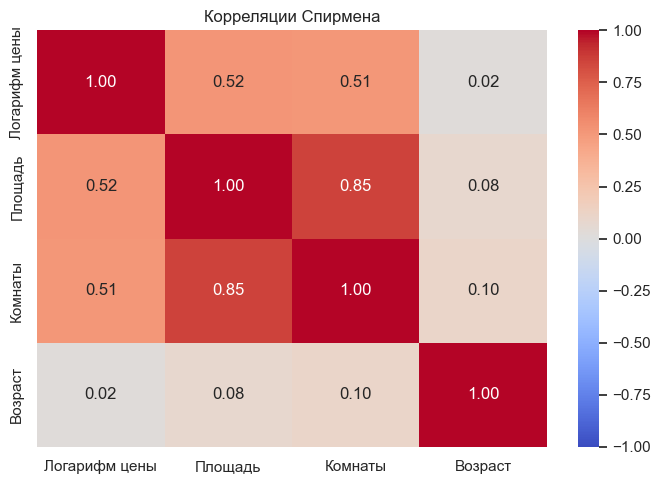

In [25]:
# Спирмен оценивает монотонную связь, не требуя нормальности цены.
corr = sale[["log_price","size_valid","rooms","age_approx"]].corr(method="spearman")
plt.figure(figsize=(7,5))
corr_ru=corr.rename(index={"log_price":"Логарифм цены","size_valid":"Площадь","rooms":"Комнаты","age_approx":"Возраст"},
                    columns={"log_price":"Логарифм цены","size_valid":"Площадь","rooms":"Комнаты","age_approx":"Возраст"})
sns.heatmap(corr_ru,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1)
plt.title("Корреляции Спирмена")
plt.tight_layout(); plt.show()

цена связана с площадью (ρ≈0,52) и комнатами (ρ≈0,51). Площадь и комнаты сильно связаны между собой (ρ≈0,85), что важно для линейной регрессии. Общая корреляция возраста с ценой около 0,02 — почти нулевая.

In [26]:
# Таблица содержит точные коэффициенты для доклада.
show_table(corr_ru.round(3).rename_axis("Признак").reset_index())

Признак,Логарифм цены,Площадь,Комнаты,Возраст
Логарифм цены,1.00,0.52,0.51,0.02
Площадь,0.52,1.00,0.85,0.09
Комнаты,0.51,0.85,1.00,0.10
Возраст,0.02,0.09,0.10,1.00


округлённые значения на карте удобны для показа, а таблица даёт точность для отчёта. Корреляция показывает связь, но не доказывает причинность.

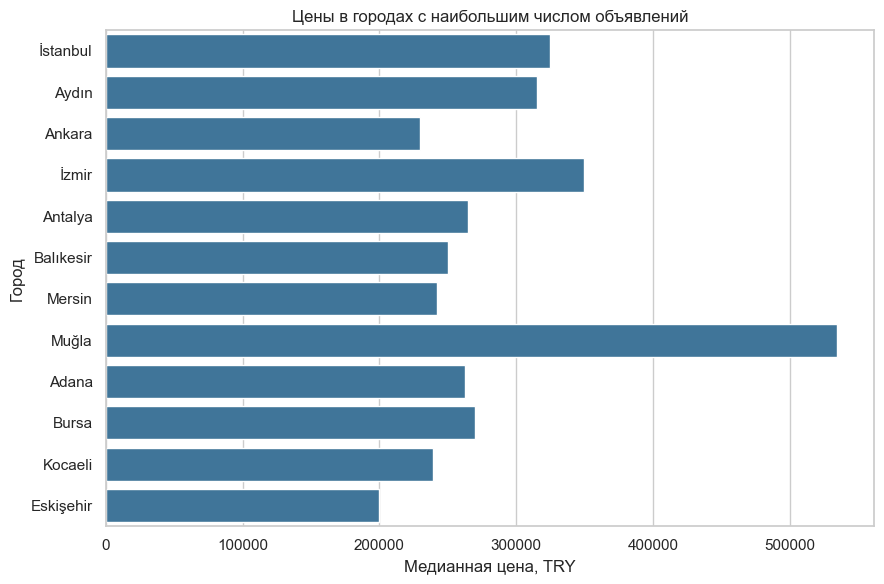

In [27]:
# Группы минимум с 500 объявлениями; медиана устойчива к редким дорогим объектам.
city_stats = sale.groupby("city").price.agg(["count","median","mean"]).query("count >= 500").sort_values("count",ascending=False).head(12)
plt.figure(figsize=(9,6))
sns.barplot(x=city_stats["median"],y=city_stats.index,color="#3178a8")
plt.xlabel("Медианная цена, TRY"); plt.ylabel("Город")
plt.title("Цены в городах с наибольшим числом объявлений")
plt.tight_layout(); plt.show()

медианная цена отличается: например, Мугла — 535 тыс. TRY, Анкара — 230 тыс. TRY. Местоположение должно входить в модель. Это сравнение не учитывает различия состава жилья между городами.

In [28]:
# Сопровождаем график числом записей и средними значениями.
show_table(city_stats.rename(columns={"count":"объявлений","median":"медиана, TRY","mean":"среднее, TRY"}).rename_axis("Город").reset_index())

Город,объявлений,"медиана, TRY","среднее, TRY"
İstanbul,70 697,325 000.00,803 107.93
Aydın,30 060,315 000.00,410 637.66
Ankara,24 898,230 000.00,317 963.66
İzmir,18 886,350 000.00,564 612.88
Antalya,17 242,265 000.00,401 930.20
Balıkesir,11 684,250 000.00,362 155.72
Mersin,8 873,242 000.00,542 719.42
Muğla,8 172,535 000.00,1 010 545.82
Adana,8 067,263 000.00,344 151.48
Bursa,7 671,270 000.00,374 855.02


в Стамбуле больше всего объявлений — 70 697. Среднее нередко выше медианы из-за дорогих объектов, поэтому для сравнения «типичного» жилья на графике использована медиана.

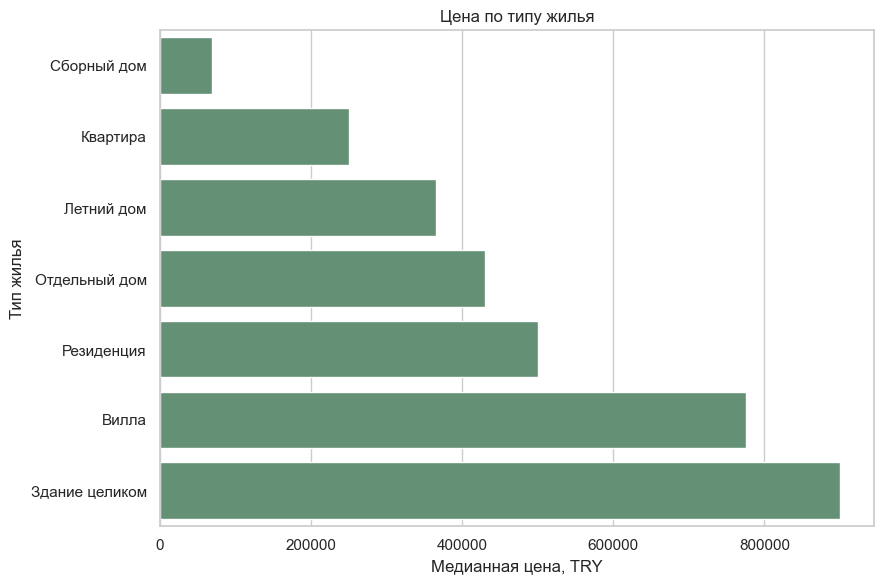

In [29]:
# Сравниваем типы жилья при достаточном числе записей.
type_stats = sale.groupby("sub_type").price.agg(["count","median","mean"]).query("count >= 500").sort_values("median")
plt.figure(figsize=(9,6))
sns.barplot(x=type_stats["median"],y=type_stats.index.map(lambda x: SUBTYPE_RU.get(x,x)),color="#5d9773")
plt.xlabel("Медианная цена, TRY"); plt.ylabel("Тип жилья")
plt.title("Цена по типу жилья")
plt.tight_layout(); plt.show()

медианная цена квартир — 250 тыс. TRY, вилл — 775 тыс. TRY. Тип объекта связан с ценой, но виллы обычно также больше по площади и находятся в других локациях.

In [30]:
# Таблица позволяет проверить размер групп и среднюю цену.
show_table(type_stats.rename(index=SUBTYPE_RU,columns={"count":"объявлений","median":"медиана, TRY","mean":"среднее, TRY"}).rename_axis("Тип жилья").reset_index())

Тип жилья,объявлений,"медиана, TRY","среднее, TRY"
Сборный дом,673,69 500.00,85 181.58
Квартира,244 914,250 000.00,354 780.81
Летний дом,5 741,365 000.00,428 952.07
Отдельный дом,7 899,430 000.00,753 782.61
Резиденция,4 249,500 000.00,1 319 870.16
Вилла,17 906,775 000.00,1 449 676.45
Здание целиком,2 209,900 000.00,2 672 778.00


квартиры составляют основную массу сегмента (244 914 записей), а другие группы гораздо меньше. Для редких типов оценки менее устойчивы; ниже порога 500 их нет на графике.

Наиболее явные кандидаты для модели — площадь, число комнат, локация и тип жилья. Возраст здания требует проверки вместе с другими признаками. Ни один отдельный график не заменяет оценку модели на отложенной выборке.

## 1.4. Пропуски и аномалии

Проверяем исходный датасет целиком. В этом разделе ничего не удаляем. Обработку пропусков и выбросов выполним на этапе 2 после разделения данных.

In [31]:
# Считаем пустые значения в каждом исходном столбце.
missing = pd.DataFrame({"пропусков":df[original_columns].isna().sum(),
                        "доля_%":df[original_columns].isna().mean().mul(100)}).sort_values("доля_%",ascending=False)
show_table(missing.rename(index=COLUMN_RU).round(2).rename_axis("Поле").reset_index())

Поле,пропусков,доля_%
Меблировка (furnished),403 487,100.00
"Площадь, м² (size)",146 006,36.19
Дата снятия (end_date),137 189,34.00
Этаж (floor_no),35 296,8.75
Этажей в здании (total_floor_count),28 021,6.94
Отопление (heating_type),27 970,6.93
Возраст здания (building_age),27 390,6.79
Валюта (price_currency),715,0.18
Цена (price),715,0.18
Номер (id),0,0.00


`furnished` пуст у всех 403 487 объектов. Площадь отсутствует у 146 006 (36,19%), `end_date` — у 137 189 (34%). Цены нет у 715 строк. Способ заполнения площади потребует проверки, потому что пропусков много.

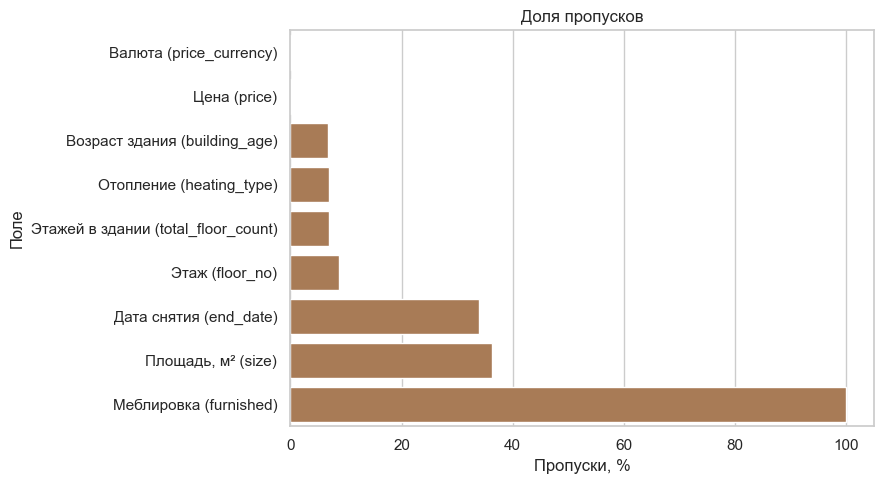

In [32]:
# График выделяет поля с ненулевой долей пропусков.
mplot = missing.loc[missing["доля_%"].gt(0)].sort_values("доля_%")
plt.figure(figsize=(9,5))
sns.barplot(x=mplot["доля_%"],y=mplot.index.map(lambda x: COLUMN_RU.get(x,x)),color="#b67a48")
plt.xlabel("Пропуски, %"); plt.ylabel("Поле"); plt.title("Доля пропусков")
plt.tight_layout(); plt.show()

главные проблемы — полностью пустой `furnished` и часто отсутствующая площадь. `end_date` может отсутствовать у активных объявлений; для прогноза на момент публикации это поле не нужно.

In [33]:
# Проверяем дубликаты, цену, площадь, даты, срок объявления и возраст.
end_dates = pd.to_datetime(df.end_date,format="%m/%d/%y",errors="coerce")
diagnostics = pd.Series({
    "дубликаты_строк":int(df[original_columns].duplicated().sum()),
    "повторные_id":int(df.id.duplicated().sum()),
    "цена_пустая":int(df.price.isna().sum()),
    "цена_неположительная":int(df.price.le(0).sum()),
    "площадь_неположительная":int(df["size"].le(0).sum()),
    "площадь_вне_15_1000":int((df["size"].notna() & ~df["size"].between(15,1000)).sum()),
    "дата_начала_некорректна":int(dates.isna().sum()),
    "дата_окончания_раньше_начала":int((end_dates<dates).sum()),
    "tom_отрицательный":int(df.tom.lt(0).sum()),
    "возраст_не_распознан_среди_заполненных":int((df.building_age.notna() & pd.to_numeric(df.building_age.replace(age_map),errors="coerce").isna()).sum())
})
show_table(diagnostics.to_frame("Количество").rename_axis("Проверка").reset_index())

Проверка,Количество
дубликаты_строк,0
повторные_id,0
цена_пустая,715
цена_неположительная,45
площадь_неположительная,0
площадь_вне_15_1000,1 140
дата_начала_некорректна,0
дата_окончания_раньше_начала,0
tom_отрицательный,0
возраст_не_распознан_среди_заполненных,0


полных дубликатов и повторных ID нет. Найдено 45 неположительных цен и 1 140 указанных площадей вне диагностического диапазона 15–1000 м². Большая площадь может принадлежать вилле или зданию, поэтому сам по себе размер не доказывает ошибку.

In [34]:
# IQR отмечает необычные значения, но не удаляет объекты.
iqr_rows = []
for col,label in [("price","Цена, TRY"),("size_valid","Площадь, м²")]:
    x = sale[col].dropna()
    q1,q3 = x.quantile([.25,.75])
    upper = q3 + 1.5*(q3-q1)
    iqr_rows.append({"признак":label,"Q1":q1,"Q3":q3,"верхняя_граница":upper,"выше_границы":int((x>upper).sum())})
show_table(pd.DataFrame(iqr_rows).rename(columns={"признак":"Признак","верхняя_граница":"Верхняя граница","выше_границы":"Выше границы"}))

Признак,Q1,Q3,Верхняя граница,Выше границы
"Цена, TRY",185 000.00,420 000.00,772 500.00,25 928
"Площадь, м²",90.00,145.00,227.50,10 234


выше статистической границы находятся примерно 25,9 тыс. цен и 10,2 тыс. площадей. Удалять все такие объекты нельзя: это заметно изменит выборку. На этапе 2 проверим их тип и локацию.

## 1.5. Промежуточные выводы и гипотезы

Эти гипотезы поддержаны EDA, но не доказывают причинную связь.

1. **Площадь связана с более высокой ценой.** Scatter и корреляция Спирмена ρ≈0,52; проверим связь внутри городов.
2. **Локация влияет на цену.** Медианы городов различаются: Мугла — 535 тыс. TRY, Анкара — 230 тыс. TRY.
3. **Тип жилья важен.** Медианы квартир и вилл — 250 и 775 тыс. TRY; проверим эффект после учёта площади и города.
4. **Число комнат полезно, но частично повторяет площадь.** Корреляция с ценой ρ≈0,51, с площадью ρ≈0,85.
5. **Возраст здания может влиять в отдельных сегментах.** Общая корреляция с ценой около 0,02, явного общего эффекта пока нет.

**Для следующего этапа:** разделить train/test до обучения импутеров и кодировщиков. Исключить `id`, `end_date`, `tom` и признаки, вычисленные из цены. Код `listing_type=1` уточнить по первоисточнику.

# Этап 2. Предварительная обработка данных

Сначала приводим цены к TRY. Затем проверяем сомнительные записи, разделяем данные и готовим признаки. Все решения по удалению записей показаны ниже; исходный CSV не меняется.

## Исходный набор

Источник — data/real_estate_data.csv. Целевая переменная — price (цена объявления). Площадь size измеряется в м².

In [ ]:
# Используем исходные столбцы набора, загруженного в этапе 1.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

ROOT = DATA_PATH.parent.parent.resolve()
raw = df[original_columns].copy()
print("Размер:", raw.shape)
display(raw.head(3))


В исходном наборе 403 487 строк. Сначала приводим цены к единой валюте, затем разбиваем объявления. Статистики заполнения и кодирования будем получать только из train.

### Приведение цены к одной валюте

Исторические курсы берём из [архива Центрального банка Турции](https://www.tcmb.gov.tr/kurlar/kurlar_en.html). Используется ForexBuying — TRY за единицу иностранной валюты. При отсутствии публикации за выходной берём последний курс до даты объявления (не старше 7 дней). Это справочный, а не фактический курс сделки. Время публикации объявления неизвестно, поэтому курс того же дня мог быть опубликован позже.

In [ ]:
# При первом запуске получаем курсы из TCMB и сохраняем локально.
from concurrent.futures import ThreadPoolExecutor
import requests
import xml.etree.ElementTree as ET

rate_file = ROOT / "data" / "external" / "tcmb_rates_2018-2019.csv"
if rate_file.exists():
    rates = pd.read_csv(rate_file)
    
else:
    dates = pd.to_datetime(raw.start_date, format="%m/%d/%y")
    def get_rate(day):
        url = f"https://www.tcmb.gov.tr/kurlar/{day:%Y%m}/{day:%d%m%Y}.xml"
        response = requests.get(url, timeout=20)
        if response.status_code == 404:
            return []
        response.raise_for_status()
        root = ET.fromstring(response.content)
        assert pd.to_datetime(root.attrib["Tarih"], format="%d.%m.%Y") == day
        return [{"rate_date": day, "currency": item.attrib["Kod"],
                 "try_per_unit": float(item.findtext("ForexBuying")) / float(item.findtext("Unit"))}
                for item in root.findall("Currency")
                if item.attrib.get("Kod") in ("EUR", "USD", "GBP")]
    with ThreadPoolExecutor(max_workers=10) as pool:
        daily = pool.map(get_rate, pd.date_range(dates.min()-pd.Timedelta(days=7), dates.max()))
        rates = pd.DataFrame(row for day in daily for row in day)
    rate_file.parent.mkdir(parents=True, exist_ok=True)
    rates.to_csv(rate_file, index=False)
rates["rate_date"] = pd.to_datetime(rates.rate_date)
assert set(rates.currency) == {"EUR", "USD", "GBP"}
assert rates.try_per_unit.gt(0).all()

print("Дней с опубликованными курсами:", rates.rate_date.nunique())
rates.head(10)

За нужный период в архиве 130 дней публикации курсов. Проверки подтверждают наличие EUR, USD и GBP и положительность курсов.

In [ ]:
# Оставляем код 1 с положительной ценой; иностранные цены умножаем на курс.
sale = raw.loc[raw.listing_type.eq(1) & raw.price.gt(0)].copy()
sale["original_currency"] = sale.price_currency
sale["listing_date"] = pd.to_datetime(sale.start_date, format="%m/%d/%y")
sale["rate_date"] = pd.NaT
sale["fx_rate"] = 1.0
for currency in ("EUR", "USD", "GBP"):
    part = sale.loc[sale.original_currency.eq(currency), ["listing_date"]]
    left = part.sort_values("listing_date").reset_index().rename(columns={"index":"row_id"})
    right = rates.loc[rates.currency.eq(currency), ["rate_date","try_per_unit"]].sort_values("rate_date")
    match = pd.merge_asof(left, right, left_on="listing_date", right_on="rate_date",
                          direction="backward", tolerance=pd.Timedelta(days=7))
    assert match.try_per_unit.notna().all(), f"Курс {currency} не найден"
    sale.loc[match.row_id.to_numpy(), "fx_rate"] = match.try_per_unit.to_numpy()
    sale.loc[match.row_id.to_numpy(), "rate_date"] = match.rate_date.to_numpy()
sale["price"] *= sale.fx_rate
sale["price_currency"] = "TRY"
foreign = sale.original_currency.ne("TRY")
lag = (sale.loc[foreign,"listing_date"]-sale.loc[foreign,"rate_date"]).dt.days
display(sale.groupby("original_currency").price.agg(["size","median"]))
print("Всего:",len(sale),"| пересчитано:",foreign.sum(),
      "| без курса:",sale.loc[foreign,"rate_date"].isna().sum(),
      "| максимальный разрыв:",lag.max(),"дня")
assert len(sale)==286392 and foreign.sum()==1924 and lag.between(0,7).all()

В итоге 286 392 объявления: 284 468 цен изначально в TRY и 1 924 пересчитаны из EUR, USD и GBP. Пропусков курса нет, максимальный разрыв с датой объявления — 3 дня. Типы 2 и 3 не добавляем: пересчёт валюты не превращает аренду или неизвестный платёж в продажу.

## 2.1. Пропуски, аномалии и разбиение

In [ ]:
# Смотрим, где и сколько пропусков.
missing = pd.DataFrame({"Пропусков":sale.isna().sum(),
                        "Доля, %":sale.isna().mean()*100}).sort_values("Доля, %",ascending=False)
display(missing)
print("Полных дубликатов:", sale.duplicated().sum())

### Проверка аномалий на конкретных объявлениях

Сначала делим объявления на train, validation и test. Для сравнения цен используем только объявления **train** того же микрорайона и типа жилья. Медиана соседей — ориентир, а не подтверждённая рыночная цена: объекты могут различаться.

| Сигнал | Проверка и решение |
| --- | --- |
| Цена ниже 1 000 TRY | Сравниваем с местными объявлениями. Исключаем как ненадёжную полную цену продажи. |
| Цена выше 50 млн TRY | Если есть минимум два местных объявления train и цена выше их медианы в 20 раз, исключаем как неподтверждённую целевую цену. Остальные оставляем с результатом проверки в реестре. |
| Площадь меньше 15 м²; больше 3 000 м² у квартиры/резиденции; больше 100 000 м² у любого объекта | Сохраняем объявление, площадь считаем пропуском. |
| Этаж выше этажности здания | Сохраняем объявление, противоречивый этаж считаем пропуском. |
| Комнаты записаны как «+» | Сохраняем объявление, число комнат считаем неизвестным. |

Так удаление записи с подозрительной ценой и исправление ошибочного признака остаются разными решениями. Число объявлений и конкретные ID показываем ниже.

In [ ]:
# Группы похожих объявлений не пересекаются между частями данных.
groups = pd.util.hash_pandas_object(
    sale[["address","sub_type","room_count","size"]], index=False)
first = GroupShuffleSplit(n_splits=1, test_size=.15, random_state=42)
dev_idx,test_idx = next(first.split(sale, groups=groups))
dev = sale.iloc[dev_idx]
second = GroupShuffleSplit(n_splits=1, test_size=.15/.85, random_state=43)
train_idx,val_idx = next(second.split(dev, groups=groups.iloc[dev_idx]))
train,val,test = dev.iloc[train_idx],dev.iloc[val_idx],sale.iloc[test_idx]
print("До проверки:",len(train),"train,",len(val),"validation,",len(test),"test")

In [ ]:
# Медианы для проверки цен получаем только из train.
peers = train.loc[train.price.ge(10_000)].groupby(["address","sub_type"]).price.agg(
    peer_count="size", peer_median="median")
sale = sale.join(peers, on=["address","sub_type"])
sale["price_ratio"] = (sale.price / sale.peer_median).where(sale.peer_count.ge(2))
area = pd.to_numeric(sale["size"], errors="coerce")
floor = pd.to_numeric(sale.floor_no, errors="coerce")
floors = pd.to_numeric(sale.total_floor_count, errors="coerce")
room_ok = sale.room_count.astype("string").str.fullmatch(r"\d+\+\d+").fillna(False)

low_price = sale.price.lt(1000)
high_unreliable = sale.price.gt(50_000_000) & sale.price_ratio.ge(20)
flags = pd.DataFrame({
    "Цена < 1 000 TRY": low_price,
    "Цена > 50 млн TRY": sale.price.gt(50_000_000),
    "Цена ≥ 20 медиан train": high_unreliable,
    "Площадь < 15 м²": area.lt(15),
    "Площадь > 3 000 м²": area.gt(3000),
    "Площадь > 100 000 м²": area.gt(100_000),
    "Этаж выше этажности": floor.gt(floors) & floors.notna(),
    "Комнаты не разобраны": sale.room_count.notna() & ~room_ok,
}, index=sale.index).fillna(False)
display(flags.sum().rename("Объявлений").to_frame())

audit = sale.loc[flags.any(axis=1),
                 ["id","sub_type","price","size","room_count","floor_no",
                  "total_floor_count","address","original_currency",
                  "peer_count","peer_median","price_ratio"]].copy()
audit["Причины"] = flags.loc[audit.index].apply(
    lambda row: ", ".join(row.index[row.to_numpy()]), axis=1)
bad_ids = set(sale.loc[low_price | high_unreliable, "id"])
audit["Решение"] = np.where(audit.id.isin(bad_ids), "исключить", "оставить")
audit["Исходная цена"] = raw.loc[audit.index, "price"]
audit["Проверка цены"] = np.where(audit.peer_count.ge(2),
                                  "есть ≥2 местных объявления train",
                                  "местных объявлений train меньше 2")
display(audit.groupby("Решение").size().rename("Объявлений").to_frame())

In [ ]:
# Смотрим конкретные записи, на которых основаны решения.
print("Высокие цены, не согласующиеся с местными объявлениями train:")
display(audit.loc[high_unreliable.loc[audit.index],
                  ["id","sub_type","price","peer_count","peer_median",
                   "price_ratio","size","address"]].sort_values("price_ratio",ascending=False))
print("Примеры сомнительных площадей:")
display(sale.loc[area.gt(100_000),["id","sub_type","price","size","address"]]
        .sort_values("size",ascending=False).head(5))
print("Примеры несогласованных этажей:")
display(sale.loc[flags["Этаж выше этажности"],
                 ["id","floor_no","total_floor_count","sub_type","address"]].head(5))
high_kept = sale.price.gt(50_000_000) & ~high_unreliable
print("Других дорогих объявлений:",int(high_kept.sum()),
      "| из них меньше двух местных объявлений train:",
      int((high_kept & ~sale.peer_count.ge(2)).sum()))
print("Дешёвых объявлений с минимум двумя местными аналогами train:",
      int((low_price & sale.peer_count.ge(2)).sum()),"из",int(low_price.sum()))

Из 163 объявлений с ценой ниже 1 000 TRY у 146 есть минимум два местных объявления train с ценой от 10 000 TRY. Каждое из этих 146 дешевле местной медианы более чем в 100 раз. Для остальных 17 местных аналогов недостаточно: исключение здесь означает ненадёжную целевую цену для задачи продажи, а не доказанную опечатку.

Из 66 объявлений дороже 50 млн TRY исключены 12. Их цены превышают местную медиану train в 22–7 692 раза. Среди 54 оставленных дорогих объектов 30 имеют достаточно аналогов, и превышение не достигает 9 раз. Для остальных 24 аналогов мало; их цены **не подтверждены и не опровергнуты**, это явно отмечено в реестре.

Неправдоподобные площади и противоречивые этажи показаны на конкретных строках выше. В этих случаях исправляется признак, а объявление остаётся.


In [ ]:
# Применяем одно и то же правило удаления к каждой части.
train,val,test = [part.loc[~part.id.isin(bad_ids)].copy()
                  for part in (train,val,test)]
sale = sale.loc[~sale.id.isin(bad_ids)].copy()
parts = (train,val,test)
group_sets = [set(groups.loc[part.index]) for part in parts]
assert all(group_sets[i].isdisjoint(group_sets[j])
           for i,j in ((0,1),(0,2),(1,2)))
display(pd.DataFrame({
    "Часть":["train","validation","test"],
    "Объявлений":[len(part) for part in parts],
    "Доля, %":[100*len(part)/len(sale) for part in parts],
}))


Цена и площадь не подгоняются по метрикам модели. После удаления ненадёжных целевых цен все остальные объявления проходят одинаковую обработку признаков. Список исключённых и оставленных ID сохранится в реестре в конце этапа.


## 2.2. Выбросы

Цены оставленных объявлений не обрезаем. Ненадёжную площадь превращаем в пропуск и заполняем по train. Остальные очень большие площади ограничиваем по границам 0,1% и 99,9%, рассчитанным только на train.

In [ ]:
# Сравниваем обычное и логарифмическое распределение цены train.
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(train.price,bins=60,ax=ax[0])
ax[0].set(title="Цена",xlabel="TRY",xlim=(0,train.price.quantile(.99)))
sns.histplot(np.log1p(train.price),bins=60,ax=ax[1])
ax[1].set(title="Логарифм цены",xlabel="log(1+TRY)")
plt.tight_layout(); plt.show()
print("Асимметрия:",round(train.price.skew(),2))

Цена сильно скошена вправо: основная масса объявлений дешевле редких дорогих объектов. Логарифм помогает увидеть форму распределения, но целевую переменную для оценки оставляем в TRY.

## 2.3–2.4. Кодирование и создание признаков

Запись 3+1 означает три комнаты и одну гостиную. Адрес разделяем на город, район и микрорайон, этаж переводим в число и сравниваем с этажностью, возраст здания — в годы. Цена за м² исключена: она вычисляется из целевой цены и вызвала бы утечку. Расстояние до центра не вычисляем без координат.

In [ ]:
# Преобразования ниже не считают статистики и одинаковы для всех частей.
def features(part):
    x=pd.DataFrame(index=part.index)
    a=part.address.fillna("").str.split("/",n=2,expand=True)
    x["city"]=a[0].replace("",np.nan)
    x["district"]=(a[0]+"/"+a[1]).where(a[1].notna())
    x["neighborhood"]=(x["district"]+"/"+a[2]).where(a[2].notna() & a[2].ne(""))
    r=part.room_count.astype("string").str.extract(r"^(\d+)\+(\d+)$")
    x["bedrooms"]=pd.to_numeric(r[0],errors="coerce")
    x["living_rooms"]=pd.to_numeric(r[1],errors="coerce")
    x["rooms_missing"]=x["bedrooms"].isna().astype(int)
    x["size_m2"]=pd.to_numeric(part["size"],errors="coerce")
    x["size_m2"]=x.size_m2.where(x.size_m2.ge(15) & x.size_m2.le(100_000) & ~(x.size_m2.gt(3000) & part.sub_type.isin(["Daire","Rezidans"])))
    x["size_missing"]=x.size_m2.isna().astype(int)
    age=part.building_age.astype("string")
    limits=age.str.extract(r"^(\d+)-(\d+) arası$").apply(pd.to_numeric,errors="coerce")
    x["building_age_years"]=pd.to_numeric(age,errors="coerce").fillna(limits.mean(axis=1)).fillna(age.map({"40 ve üzeri":40}))
    x["age_missing"]=x.building_age_years.isna().astype(int)
    x["is_new_building"]=x.building_age_years.eq(0).fillna(False).astype(int)
    floors=part.total_floor_count.astype("string")
    x["building_floors"]=pd.to_numeric(floors,errors="coerce").fillna(floors.map({"10-20 arası":15,"20 ve üzeri":20}))
    floor=part.floor_no.astype("string")
    x["floor_number"]=pd.to_numeric(floor,errors="coerce").fillna(floor.map({"Yüksek Giriş":1,"Giriş Katı":0,"Zemin Kat":0,"Bahçe katı":0,"20 ve üzeri":20}))
    basement=pd.to_numeric(floor.str.extract(r"^Kot (\d+)$")[0],errors="coerce")
    x["floor_number"]=x.floor_number.fillna(-basement)
    x["floor_conflict"]=(x.floor_number.gt(x.building_floors) & x.building_floors.notna()).fillna(False).astype(int)
    x.loc[x.floor_conflict.eq(1),"floor_number"]=np.nan
    x["floor_ratio"]=x.floor_number/x.building_floors.where(x.building_floors.gt(0))
    x["is_top_floor"]=(x.floor_number.eq(x.building_floors)&x.building_floors.notna()).fillna(False).astype(int)
    x["sub_type"]=part.sub_type
    x["heating_type"]=part.heating_type
    return x
X_train,X_val,X_test=[features(part) for part in parts]
y_train,y_val,y_test=[part.price.copy() for part in parts]
display(X_train.head(3))
print("Доля строк с микрорайоном в train, %:",round(100*X_train.neighborhood.notna().mean(),2))
print("Уникальных полных микрорайонов в train:",X_train.neighborhood.nunique())
print("Строк с неразобранными комнатами:",X_train.rooms_missing.sum())

Адрес разобран до микрорайона. Неизвестные комнаты, площадь и противоречивый этаж остаются пропусками, а не превращаются в ноль. Модель не получает цену, курс, ID и дату снятия объявления как признаки.

In [ ]:
# Медианы площади получаем только по train.
by_neighborhood=X_train.groupby(["neighborhood","sub_type"]).size_m2.agg(["median","count"])
by_neighborhood=by_neighborhood.loc[by_neighborhood["count"].ge(20),"median"]
by_district=X_train.groupby(["district","sub_type"]).size_m2.agg(["median","count"])
by_district=by_district.loc[by_district["count"].ge(20),"median"]
by_type=X_train.groupby("sub_type").size_m2.median()
overall=X_train.size_m2.median()
def fill_area(x):
    result=x.copy()
    for keys,medians in [(["neighborhood","sub_type"],by_neighborhood),
                         (["district","sub_type"],by_district)]:
        index=pd.MultiIndex.from_frame(result[keys])
        local=pd.Series(medians.reindex(index).to_numpy(),index=result.index)
        result["size_m2"]=result.size_m2.fillna(local)
    result["size_m2"]=result.size_m2.fillna(result.sub_type.map(by_type)).fillna(overall)
    return result
before=[x.size_m2.isna().sum() for x in (X_train,X_val,X_test)]
X_train,X_val,X_test=[fill_area(x) for x in (X_train,X_val,X_test)]
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Пропусков площади до":before,
                      "После":[x.size_m2.isna().sum() for x in (X_train,X_val,X_test)]}))
print("Групп микрорайон+тип с ≥20 известными площадями:",len(by_neighborhood))
print("Общая медиана train:",overall)


Все пропуски площади заполнены без удаления строк. Если данных достаточно, медиана учитывает микрорайон и тип жилья; для малых групп предусмотрены район, тип и общая медиана. Все уровни вычислены только по train.

In [ ]:
# Пороги площади также получаем только из train.
low,high=X_train.size_m2.quantile([.001,.999])
for x in (X_train,X_val,X_test):
    x["size_m2"]=x.size_m2.clip(low,high)
print("Границы площади, м²:",round(low,1),"—",round(high,1))

Площадь ограничена одинаково во всех трёх частях. Строки не удалены, целевая цена не изменена.

## 2.5. Кодирование и масштабирование

Город, район, микрорайон, тип жилья и отопление — номинальные категории, поэтому применяем One-Hot Encoding. Редкие категории объединяем. Для линейной модели числа стандартизируем; для деревьев оставляем без масштабирования.

In [ ]:
# Все заполнители, кодировщик и скалер обучаются только на train.
num=["size_m2","bedrooms","living_rooms","building_age_years","building_floors",
     "floor_number","floor_ratio","floor_conflict","size_missing","rooms_missing","age_missing","is_new_building","is_top_floor"]
cat=["city","district","neighborhood","sub_type","heating_type"]
def build_encoder(scale):
    steps=[("missing",SimpleImputer(strategy="median"))]
    if scale: steps.append(("scale",StandardScaler()))
    return ColumnTransformer([
        ("num",Pipeline(steps),num),
        ("cat",Pipeline([("missing",SimpleImputer(strategy="most_frequent")),
                         ("onehot",OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                 min_frequency=100))]),cat)
    ],sparse_threshold=.3)
linear_preprocessor=build_encoder(True)
tree_preprocessor=build_encoder(False)
X_train_linear=linear_preprocessor.fit_transform(X_train)
X_val_linear=linear_preprocessor.transform(X_val)
X_test_linear=linear_preprocessor.transform(X_test)
X_train_tree=tree_preprocessor.fit_transform(X_train)
X_val_tree=tree_preprocessor.transform(X_val)
X_test_tree=tree_preprocessor.transform(X_test)
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Строк":[x.shape[0] for x in (X_train_linear,X_val_linear,X_test_linear)],
                      "Признаков":[x.shape[1] for x in (X_train_linear,X_val_linear,X_test_linear)]}))

Число столбцов совпадает во всех частях: новые категории не ломают обработку. Важное правило для следующего этапа: при кросс-валидации кодировщик и заполнители должны обучаться внутри каждого тренировочного фолда.

## 2.6. Проверка результата

Проверяем конечность значений и мультиколлинеарность основных числовых признаков с помощью VIF. Новые признаки сами по себе не гарантируют отсутствие корреляции.

In [ ]:
from scipy import sparse
for matrix in (X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree):
    values=matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    assert np.isfinite(values).all()
vif_cols=["size_m2","bedrooms","living_rooms","building_age_years",
          "building_floors","floor_number","floor_ratio"]
vif_data=pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train[vif_cols]),
                      columns=vif_cols).sample(n=min(20000,len(X_train)),random_state=42)
vif_matrix=np.column_stack([np.ones(len(vif_data)),vif_data.to_numpy()])
vif=pd.DataFrame({"Признак":vif_cols,
                  "VIF":[variance_inflation_factor(vif_matrix,i+1) for i in range(len(vif_cols))]})
display(vif.sort_values("VIF",ascending=False))
print("Максимальный VIF:",round(vif.VIF.max(),2))
print("NaN и бесконечностей в итоговых матрицах нет")

Матрицы не содержат пропусков и бесконечностей. Если все VIF ниже 5, существенной мультиколлинеарности среди этих числовых признаков не обнаружено; окончательный выбор признаков сделаем по результатам моделей.

In [ ]:
# Сохраняем полный реестр решений и ID частей.
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
audit_path = processed / "anomaly_audit_main_v1.3.csv"
audit.to_csv(audit_path, index=False, encoding="utf-8-sig")
split_ids = pd.concat([
    pd.DataFrame({"id":train.id,"split":"train"}),
    pd.DataFrame({"id":val.id,"split":"validation"}),
    pd.DataFrame({"id":test.id,"split":"test"}),
]).sort_values("id")
split_path = processed / "split_ids_main_v1.3.csv"
split_ids.to_csv(split_path, index=False)
print("Реестр:", len(audit), "объявления →", audit_path)
print("Осталось для модели:", len(split_ids), "→", split_path)

## Итог этапа 2

- Цены сегмента продажи приведены к TRY.
- Подозрительные цены сравнены только с train-объявлениями того же адреса и типа. Для каждого ID в `data/processed/anomaly_audit_main_v1.3.csv` указаны причина, численность группы, её медиана, отношение цен и решение.
- Записи с ненадёжной целевой ценой исключены. Остальные дорогие объекты сохранены и видны в реестре; для 24 из них местных аналогов недостаточно для уверенной оценки.
- Ошибочные площадь и этаж становятся пропусками признаков; площадь заполняется по медианам train.
- Групповые train/validation/test не пересекаются, статистики преобразований вычислены на train.

После изменения данных модель этапа 3 нужно обучить заново. Сравнение с местными объявлениями — основание для учебной очистки, а не подтверждение истинной рыночной цены.